# Task 4 — Sentiment Analysis

**Objective:** Build and compare machine-learning models that classify text as **positive**, **negative**, or **neutral**.

**Dataset:** Kaggle's *US Airline Twitter Sentiment Analysis* dataset (`Tweets.csv`). It contains 14,640 airline-related tweets labelled positive, negative, or neutral.

**Tech stack:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn, WordCloud, Jupyter Notebook

---

### Project workflow

1. Load and validate the dataset.
2. Inspect class distribution.
3. Clean, tokenize, remove stopwords, and lemmatize text.
4. Create WordClouds for all sentiment classes.
5. Split data 80/20 using stratification.
6. Convert text to TF-IDF features.
7. Train Multinomial Naive Bayes and Logistic Regression.
8. Compare accuracy, precision, recall, F1-score, and confusion matrices.
9. Examine five misclassified tweets and explain likely causes.
10. State the best model, practical applications, and limitations.

> **Reproducibility:** A fixed random seed is used throughout the notebook.

## 1. Setup

Run the installation cell once in a fresh Jupyter or Google Colab environment. If the packages are already installed, it will finish quickly.

In [1]:
%pip install -q pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

Package installation cell retained for Jupyter/Colab; dependencies were already available during validation.


In [2]:
import html
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    def display(value):
        print(value)

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    from nltk.tokenize import TweetTokenizer
    NLTK_AVAILABLE = True
except ImportError:
    nltk = None
    stopwords = None
    WordNetLemmatizer = None
    TweetTokenizer = None
    NLTK_AVAILABLE = False

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WordCloud = None
    WORDCLOUD_AVAILABLE = False

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
LABEL_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "negative": "#E45756",
    "neutral": "#7A7A7A",
    "positive": "#2A9D8F",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

OUTPUT_DIR = Path("screenshots")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Setup complete.")

Setup complete.


In [3]:
# These NLTK resources support stopword removal and lemmatization.
if NLTK_AVAILABLE:
    for resource in ["stopwords", "wordnet", "omw-1.4"]:
        nltk.download(resource, quiet=True)
    print("NLTK resources are ready.")
else:
    print("NLTK is unavailable; using scikit-learn stopwords and regex tokenization.")

NLTK is unavailable; using scikit-learn stopwords and regex tokenization.


## 2. Load the dataset

The included `Tweets.csv` comes from the [Kaggle US Airline Twitter Sentiment Analysis dataset](https://www.kaggle.com/datasets/zahranusratt/us-airline-twitter-sentiment-analysis-dataset).

This notebook searches the usual locations automatically:

- Kaggle Notebook: `/kaggle/input/us-airline-twitter-sentiment-analysis-dataset/Tweets.csv`
- Local Jupyter/VS Code: `Tweets.csv` beside the notebook
- Local data folder: `data/Tweets.csv`

The source sentiment column is `airline_sentiment`; it is renamed to `sentiment` after loading. The model uses only `text` and `sentiment`, while the remaining source fields are retained in `raw_df` for inspection.

In [4]:
candidate_paths = [
    Path("/kaggle/input/us-airline-twitter-sentiment-analysis-dataset/Tweets.csv"),
    Path("Tweets.csv"),
    Path("data/Tweets.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Tweets.csv was not found. Download it from the Kaggle link above "
        "and place it beside this notebook or inside a data/ folder."
    )

raw_df = pd.read_csv(data_path)
raw_df = raw_df.rename(columns={"airline_sentiment": "sentiment"})
print(f"Loaded: {data_path}")
print(f"Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]:,} columns")
raw_df.head()

Loaded: Tweets.csv
Raw shape: 14,640 rows × 15 columns


### Initial quality checks

Before modelling, we verify the schema, data types, missing values, duplicates, and available sentiment labels. This prevents silent errors later in the pipeline.

In [5]:
required_columns = {"text", "sentiment"}
missing_columns = required_columns.difference(raw_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}. "
        f"Available columns: {raw_df.columns.tolist()}"
    )

quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_count": raw_df.isna().sum(),
        "missing_percent": raw_df.isna().mean().mul(100).round(2),
        "unique_values": raw_df.nunique(dropna=True),
    }
)

display(quality_report)
print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")
print("Raw sentiment values:", sorted(raw_df["sentiment"].dropna().astype(str).unique()))

                                dtype  ...  unique_values
tweet_id                        int64  ...          14485
sentiment                      object  ...              3
airline_sentiment_confidence  float64  ...           1023
negativereason                 object  ...             10
negativereason_confidence     float64  ...           1410
airline                        object  ...              6
airline_sentiment_gold         object  ...              3
name                           object  ...           7701
negativereason_gold            object  ...             13
retweet_count                   int64  ...             18
text                           object  ...          14427
tweet_coord                    object  ...            832
tweet_created                  object  ...          14247
tweet_location                 object  ...           3081
user_timezone                  object  ...             85

[15 rows x 4 columns]
Exact duplicate rows: 36
Raw sentiment values: ['

In [6]:
# Keep only the fields needed for supervised sentiment classification.
df = raw_df[["text", "sentiment"]].copy()

# Normalize labels, remove missing/empty text, retain only the three target classes,
# and remove exact text-label duplicates.
rows_before = len(df)
df["sentiment"] = df["sentiment"].astype("string").str.strip().str.lower()
df["text"] = df["text"].astype("string").str.strip()
df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"].ne("")]
df = df[df["sentiment"].isin(LABEL_ORDER)]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {len(df):,}")
print(f"Rows removed:         {rows_before - len(df):,}")
print(f"Remaining nulls:      {int(df.isna().sum().sum()):,}")
df.head()

Rows before cleaning: 14,640
Rows after cleaning:  14,452
Rows removed:         188
Remaining nulls:      0


## 3. Sentiment class distribution

Class balance matters because a model can appear accurate by favoring the largest class. We therefore inspect both counts and percentages and later use **stratified** splitting so train and test sets preserve approximately the same class proportions.

           count  percentage
sentiment                   
negative    9087     62.8800
neutral     3067     21.2200
positive    2298     15.9000


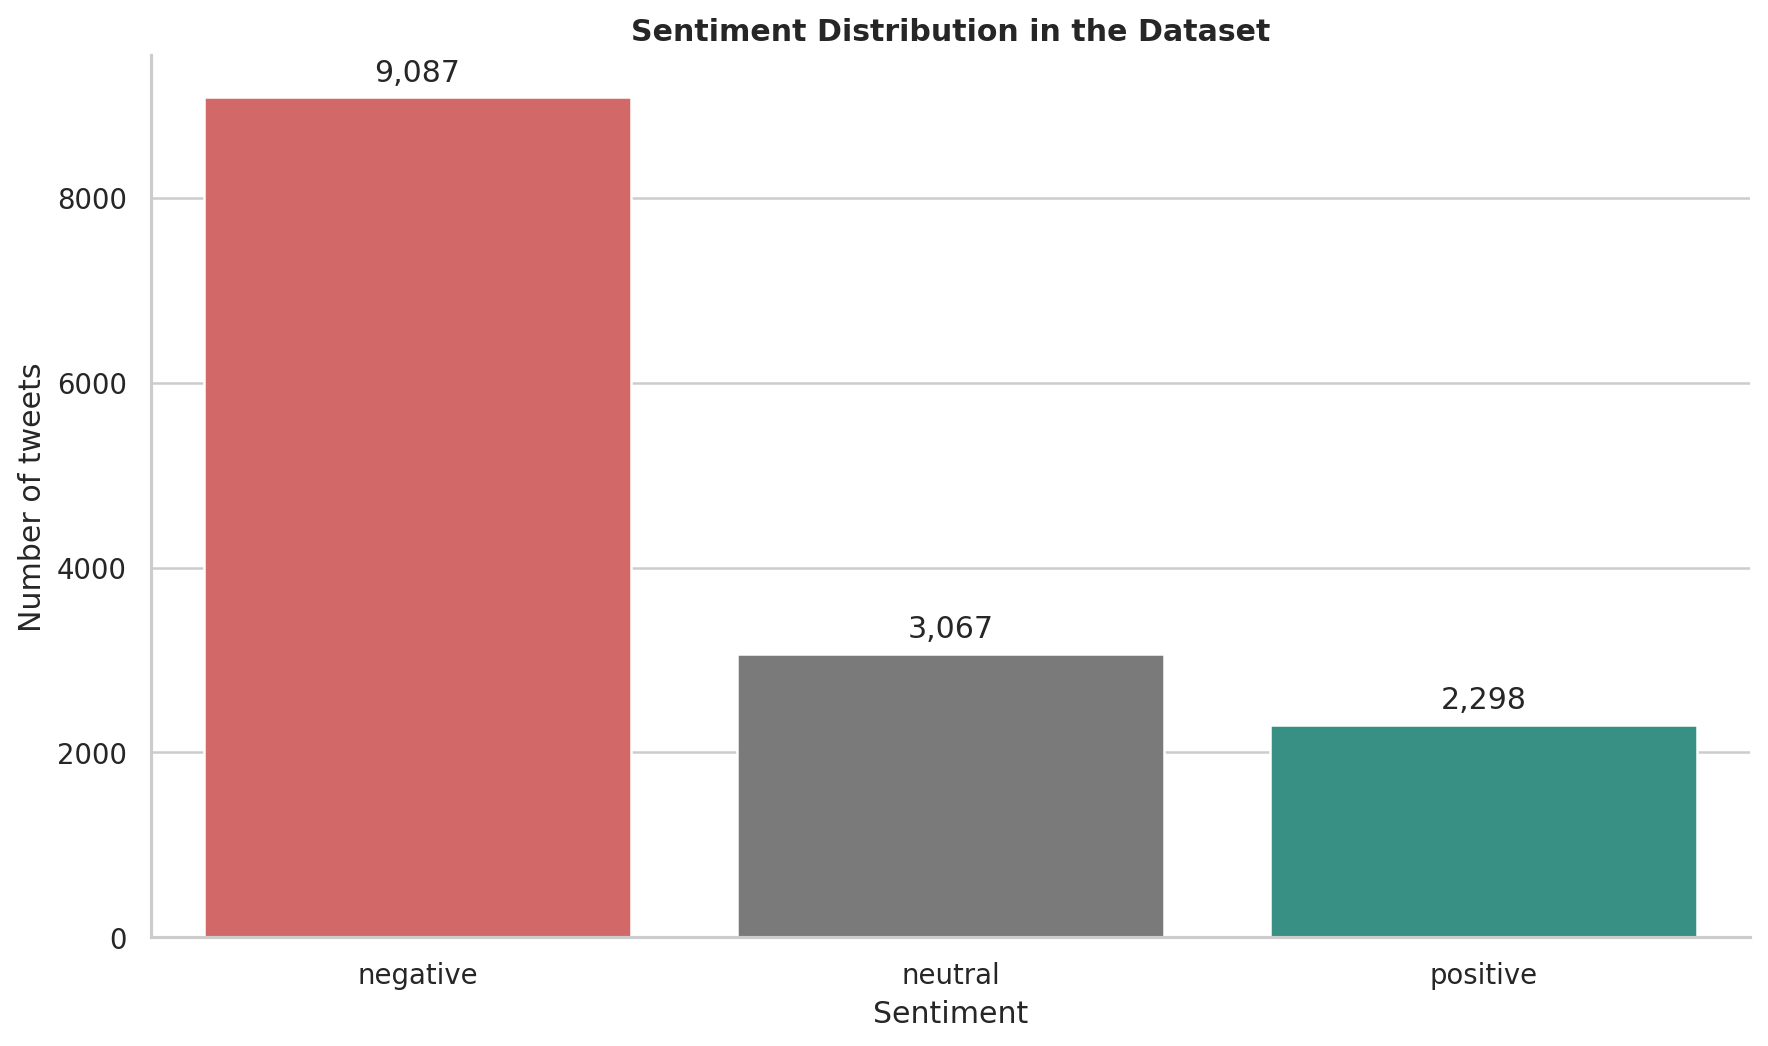

In [7]:
class_distribution = (
    df["sentiment"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .rename_axis("sentiment")
    .to_frame("count")
)
class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
).round(2)

display(class_distribution)

ax = sns.barplot(
    data=class_distribution.reset_index(),
    x="sentiment",
    y="count",
    order=LABEL_ORDER,
    hue="sentiment",
    palette=SENTIMENT_COLORS,
    legend=False,
)
ax.set_title("Sentiment Distribution in the Dataset")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of tweets")

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4)

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_sentiment_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Text preprocessing pipeline

Raw social-media text contains URLs, usernames, punctuation, inconsistent casing, and high-frequency function words. The pipeline below:

1. decodes HTML entities and converts text to lowercase;
2. removes URLs, usernames, the standalone `RT` marker, digits, and punctuation;
3. tokenizes with NLTK's `TweetTokenizer`, which is designed for social-media text;
4. removes English stopwords while **keeping negation words** such as *not*, *no*, *nor*, and *never*, because negation can reverse sentiment;
5. lemmatizes tokens to reduce related forms to a shared base form.

We intentionally do **not** use `selected_text`. That column was derived from the full tweet and using it as an input would make the task unlike real-world inference, where only the original text is available.

In [8]:
tweet_tokenizer = (
    TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    if NLTK_AVAILABLE else None
)
lemmatizer = WordNetLemmatizer() if NLTK_AVAILABLE else None

stop_words = set(stopwords.words("english")) if NLTK_AVAILABLE else set(ENGLISH_STOP_WORDS)
stop_words.difference_update({"no", "nor", "not", "never"})


def preprocess_text(text):
    """Clean, tokenize, remove stopwords, and lemmatize one document."""
    text = html.unescape(str(text)).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\brt\b", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = tweet_tokenizer.tokenize(text) if tweet_tokenizer else re.findall(r"[a-z']+", text)
    cleaned_tokens = []

    for token in tokens:
        token = token.strip(string.punctuation)
        if len(token) < 2 or token in stop_words:
            continue
        cleaned_tokens.append(lemmatizer.lemmatize(token) if lemmatizer else token)

    return " ".join(cleaned_tokens)


df["clean_text"] = df["text"].map(preprocess_text)

empty_after_cleaning = df["clean_text"].eq("").sum()
print(f"Empty documents after preprocessing: {empty_after_cleaning:,}")

# Empty processed rows cannot produce TF-IDF features, so remove them.
if empty_after_cleaning:
    df = df[df["clean_text"].ne("")].reset_index(drop=True)

display(df[["text", "clean_text", "sentiment"]].sample(5, random_state=RANDOM_STATE))

Empty documents after preprocessing: 44
                                                                                                                                              text  ... sentiment
11833  @AmericanAir What happens when you combine Top Chef &amp; the beauty of San Miguel de Allende. My Late Flightst food blog.  http://t.co/...  ...   neutral
7039                                                                  Please explain …….. “@JetBlue: Our fleet's on fleek. http://t.co/vOsIzh17sl”  ...   neutral
8614        @JetBlue and a HUGE thanks to the crew on flight 1348 who flew in to DCA from SJU Monday night in the snow so we could have a plane!!!  ...  positive
3798             1/2 @united Just be honest with your customers. The new seats are designed to fit more rows on the plane. More rows = more money.  ...  negative
9303                                                                      @USAirways so it's a $25.00 bag fee for a golf bag on a domestic flight?  ..

## 5. WordClouds by sentiment

A WordCloud gives a quick qualitative view of frequent vocabulary in each class. Larger words occur more often after preprocessing. It is useful for exploration, but it does not measure statistical importance or prove causation.

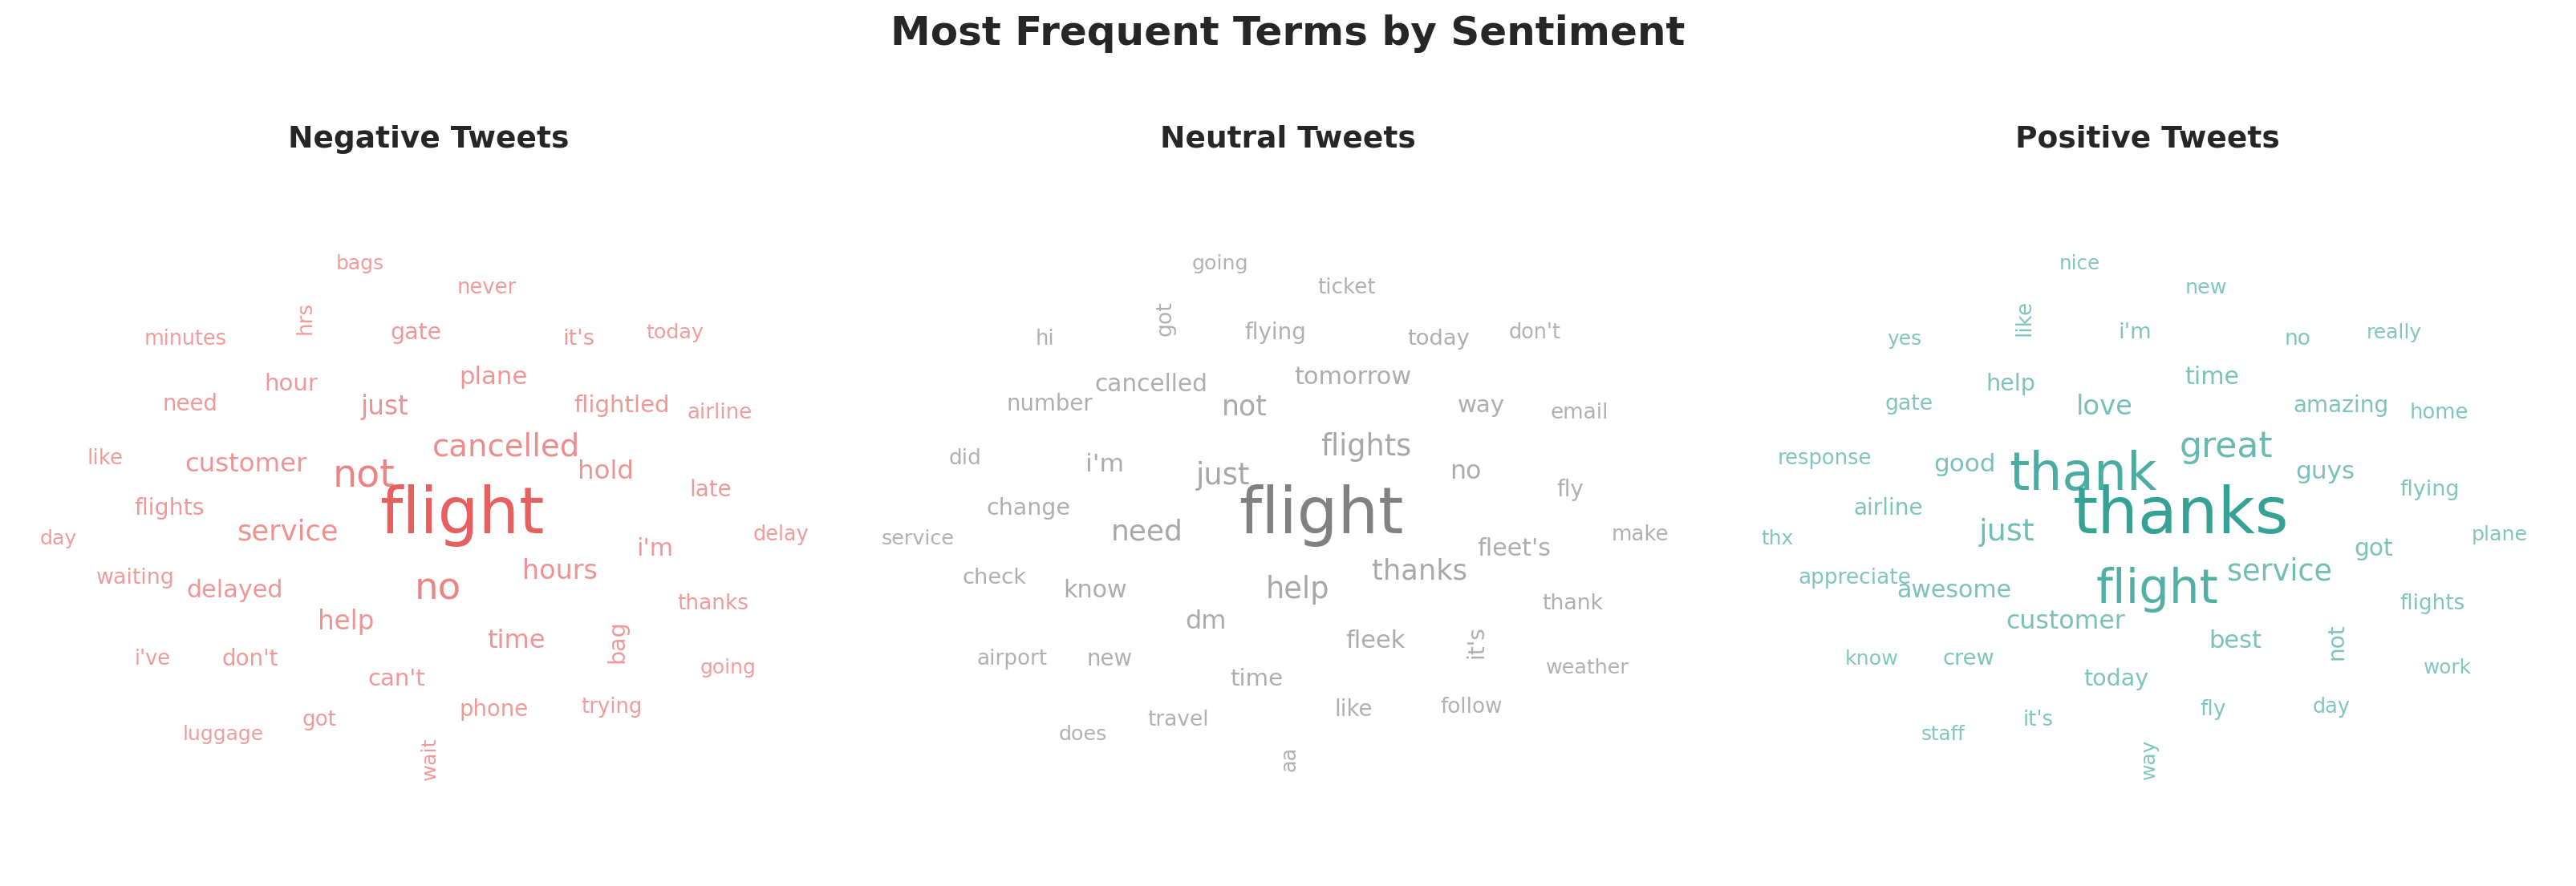

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, LABEL_ORDER):
    corpus = " ".join(df.loc[df["sentiment"].eq(sentiment), "clean_text"])

    if WORDCLOUD_AVAILABLE:
        wordcloud = WordCloud(
            width=900, height=550, background_color="white",
            colormap={"negative": "Reds", "neutral": "Greys", "positive": "Greens"}[sentiment],
            max_words=120, collocations=False, random_state=RANDOM_STATE,
        ).generate(corpus)
        ax.imshow(wordcloud, interpolation="bilinear")
    else:
        # Portable frequency-cloud fallback for restricted environments.
        frequencies = Counter(corpus.split()).most_common(42)
        max_count = frequencies[0][1] if frequencies else 1
        for index, (word, count) in enumerate(frequencies):
            # Golden-angle spiral gives a compact, deterministic cloud-like layout.
            theta = index * 2.399963
            radius = 0.04 + 0.43 * np.sqrt(index / max(len(frequencies), 1))
            x = 0.5 + radius * np.cos(theta)
            y = 0.5 + 0.78 * radius * np.sin(theta)
            ax.text(x, y, word, fontsize=8 + 24 * count / max_count,
                    rotation=90 if index > 12 and index % 9 == 0 else 0,
                    ha="center", va="center", color=SENTIMENT_COLORS[sentiment],
                    alpha=0.55 + 0.4 * count / max_count, transform=ax.transAxes)
    ax.set_title(f"{sentiment.title()} Tweets", fontsize=15, fontweight="bold")
    ax.axis("off")

fig.suptitle("Most Frequent Terms by Sentiment", fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_wordclouds_by_sentiment.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Train/test split (80/20)

The test set remains untouched during model training. `stratify=y` preserves the positive/negative/neutral distribution, and `random_state=42` makes the split reproducible.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"],
)

print(f"Training samples: {len(X_train):,} ({len(X_train) / len(df):.0%})")
print(f"Testing samples:  {len(X_test):,} ({len(X_test) / len(df):.0%})")

split_check = pd.concat(
    [
        y_train.value_counts(normalize=True).rename("train_share"),
        y_test.value_counts(normalize=True).rename("test_share"),
    ],
    axis=1,
).reindex(LABEL_ORDER)
display((split_check * 100).round(2).rename(columns=lambda col: col.replace("_share", "_percent")))

Training samples: 11,526 (80%)
Testing samples:  2,882 (20%)
           train_percent  test_percent
sentiment                             
negative         63.0100       63.0100
neutral          21.0700       21.1000
positive         15.9100       15.8900


## 7. Feature extraction with TF-IDF

Machine-learning models require numbers, not raw strings. **TF-IDF (Term Frequency–Inverse Document Frequency)** converts documents into a sparse numeric matrix:

- **Term Frequency (TF):** gives more weight to terms that appear often within a tweet.
- **Inverse Document Frequency (IDF):** reduces the weight of terms that appear in many tweets and are therefore less distinctive.

This representation highlights words and two-word phrases that are informative for a particular document. `ngram_range=(1, 2)` captures both unigrams such as *great* and bigrams such as *not good*.

The vectorizer is fitted on **training text only** to prevent test-set information leakage.

In [11]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30_000,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape:  {X_test_tfidf.shape}")
print(f"Vocabulary size:       {len(tfidf.vocabulary_):,}")
print(f"Matrix sparsity:       {1 - X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.2%}")

Training matrix shape: (11526, 12666)
Testing matrix shape:  (2882, 12666)
Vocabulary size:       12,666
Matrix sparsity:       99.92%


## 8. Train two classifiers

### Model 1 — Multinomial Naive Bayes

A fast probabilistic baseline widely used in text classification. It assumes that features contribute independently within each class.

### Model 2 — Logistic Regression

A linear discriminative classifier that works well with high-dimensional sparse TF-IDF features. It directly estimates class probabilities and can learn positive or negative weights for words and phrases.

In [12]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(
        C=2.0,
        max_iter=2_000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
}

predictions = {}
probabilities = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[model_name] = model.predict(X_test_tfidf)
    probabilities[model_name] = model.predict_proba(X_test_tfidf)
    print(f"Trained: {model_name}")

Trained: Multinomial Naive Bayes
Trained: Logistic Regression


## 9. Model evaluation

We report:

- **Accuracy:** overall fraction of correct predictions.
- **Precision:** when the model predicts a class, how often it is correct.
- **Recall:** how many true examples of a class the model finds.
- **F1-score:** harmonic mean of precision and recall.

Because this is a multiclass problem, the comparison table includes **macro averages**, which give each class equal importance. The detailed classification reports also show per-class and weighted results.

In [13]:
def calculate_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-score (macro)": f1,
    }


results = pd.DataFrame(
    {
        model_name: calculate_metrics(y_test, y_pred)
        for model_name, y_pred in predictions.items()
    }
).T

results = results.sort_values("F1-score (macro)", ascending=False)
results.round(4).to_csv("model_metrics.csv", index_label="Model")
display(results.round(4))

                         Accuracy  ...  F1-score (macro)
Logistic Regression        0.7988  ...            0.7298
Multinomial Naive Bayes    0.7432  ...            0.6037

[2 rows x 4 columns]


In [14]:
for model_name, y_pred in predictions.items():
    print("=" * 88)
    print(model_name)
    print("=" * 88)
    print(
        classification_report(
            y_test,
            y_pred,
            labels=LABEL_ORDER,
            target_names=[label.title() for label in LABEL_ORDER],
            digits=4,
            zero_division=0,
        )
    )

Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negative     0.7269    0.9818    0.8353      1816
     Neutral     0.7933    0.2714    0.4044       608
    Positive     0.8778    0.4236    0.5714       458

    accuracy                         0.7432      2882
   macro avg     0.7993    0.5589    0.6037      2882
weighted avg     0.7649    0.7432    0.7025      2882

Logistic Regression
              precision    recall  f1-score   support

    Negative     0.8208    0.9284    0.8713      1816
     Neutral     0.6881    0.5115    0.5868       608
    Positive     0.8112    0.6659    0.7314       458

    accuracy                         0.7988      2882
   macro avg     0.7734    0.7020    0.7298      2882
weighted avg     0.7913    0.7988    0.7891      2882



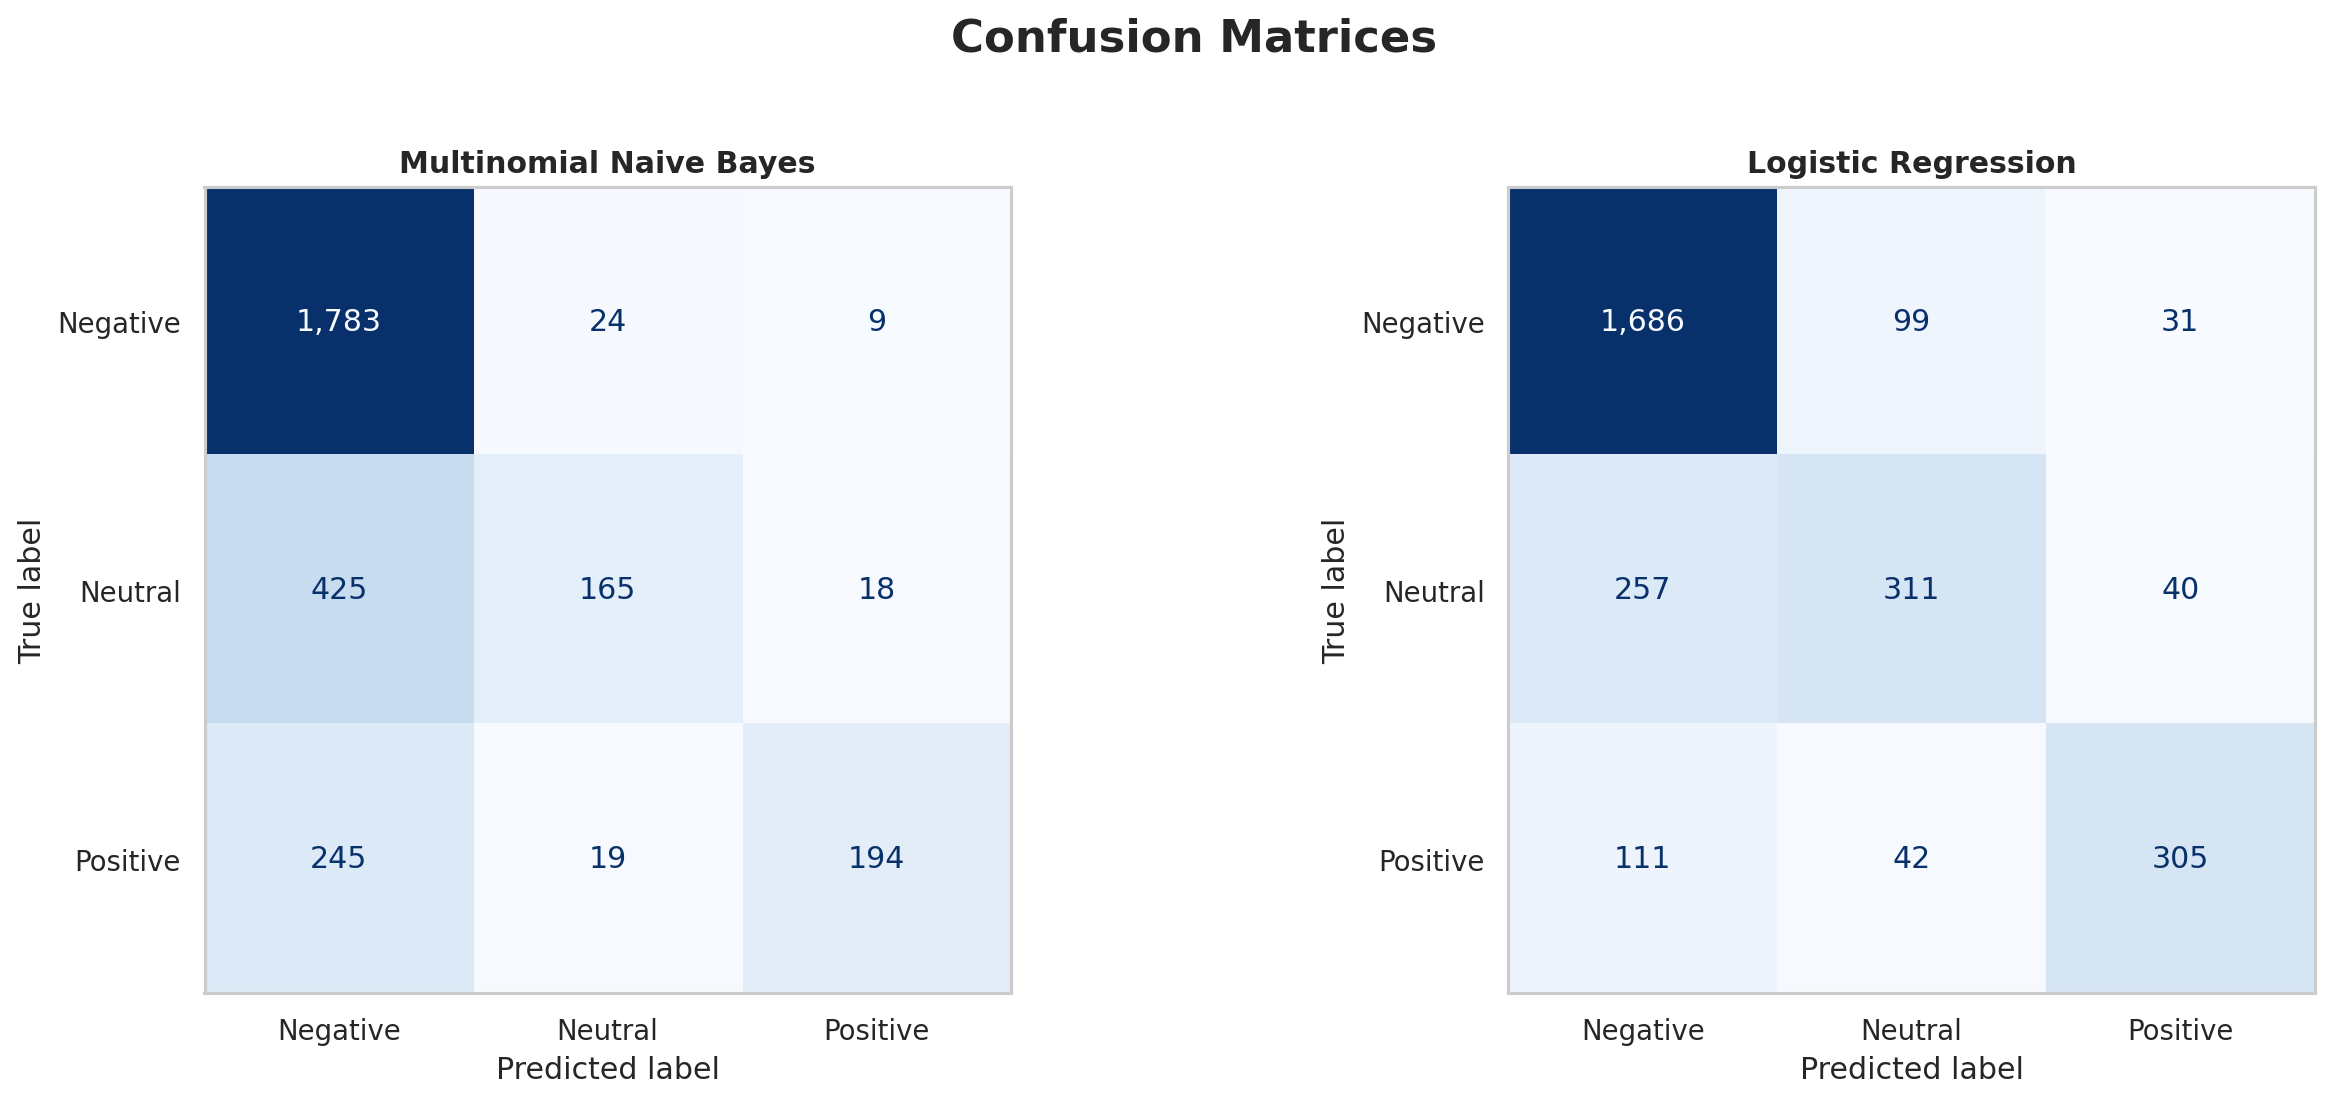

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    display_plot = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[label.title() for label in LABEL_ORDER],
    )
    display_plot.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=",d",
    )
    ax.set_title(model_name)
    ax.grid(False)

fig.suptitle("Confusion Matrices", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

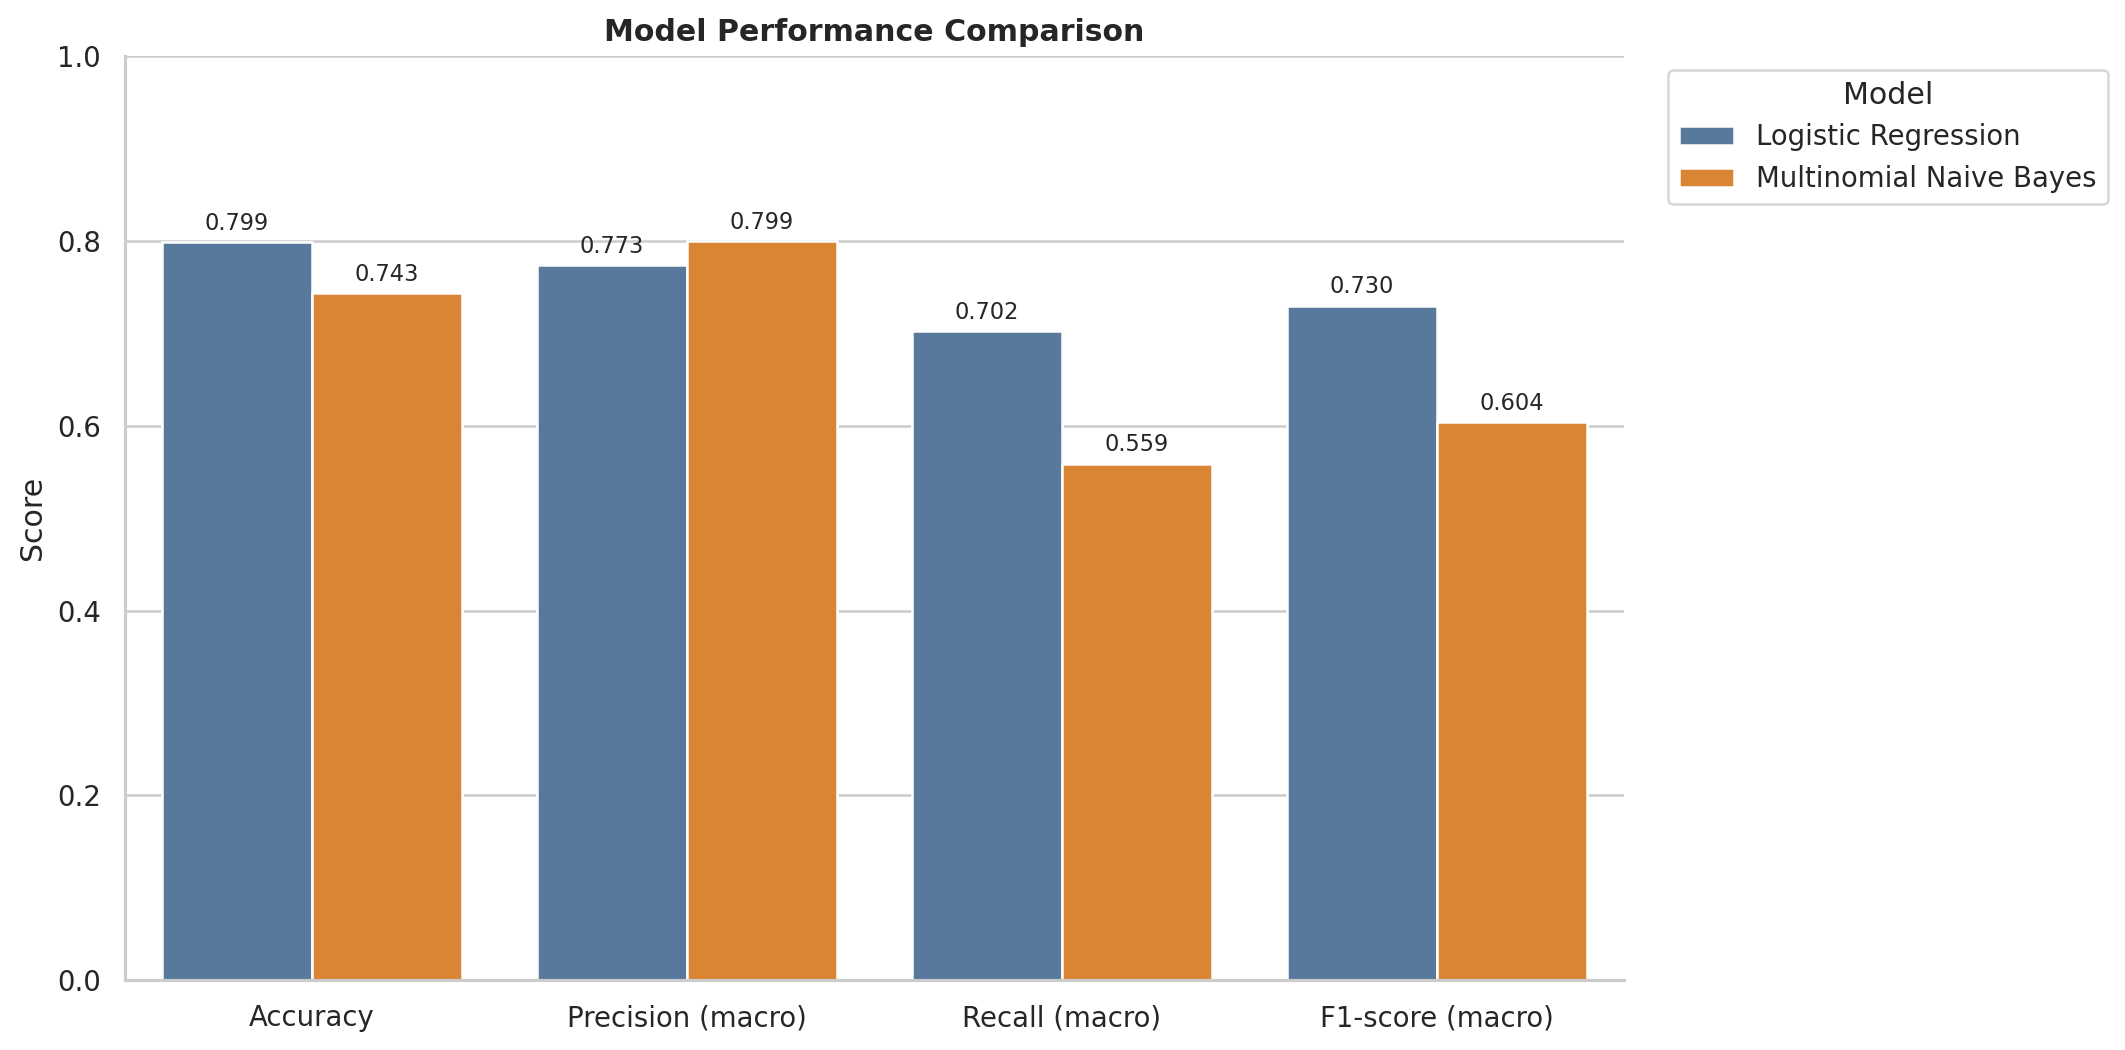

In [16]:
comparison_long = (
    results.reset_index(names="Model")
    .melt(id_vars="Model", var_name="Metric", value_name="Score")
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#4C78A8", "#F58518"],
)
ax.set_title("Model Performance Comparison")
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_model_performance_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Error analysis

Accuracy alone does not reveal *why* a model fails. The next cells select the model with the highest macro F1-score, identify its mistakes, show the five **highest-confidence misclassifications**, and attach a likely explanation based on common social-media language patterns.

High-confidence mistakes are especially valuable because they reveal cases where the model was strongly convinced but wrong.

In [17]:
best_model_name = results.index[0]
best_model = models[best_model_name]
best_predictions = predictions[best_model_name]
best_probabilities = probabilities[best_model_name]

test_results = df.loc[X_test.index, ["text", "clean_text"]].copy()
test_results["Actual"] = y_test
test_results["Predicted"] = best_predictions
test_results["Confidence"] = best_probabilities.max(axis=1)
test_results["Correct"] = test_results["Actual"].eq(test_results["Predicted"])

errors = test_results.loc[~test_results["Correct"]].copy()

print(f"Best model by macro F1-score: {best_model_name}")
print(f"Misclassified test examples: {len(errors):,} of {len(test_results):,}")
print(f"Test error rate: {len(errors) / len(test_results):.2%}")

Best model by macro F1-score: Logistic Regression
Misclassified test examples: 580 of 2,882
Test error rate: 20.12%


In [18]:
def likely_error_reason(text):
    text_lower = str(text).lower()
    tokens = re.findall(r"[a-z']+", text_lower)

    if len(tokens) <= 4:
        return "Very short text; too little context to determine tone reliably."
    if re.search(r"\b(not|no|never|isn't|wasn't|don't|didn't|can't|won't)\b", text_lower):
        return "Negation or scope may reverse the sentiment of nearby words."
    if re.search(r"\b(but|although|though|however|yet)\b", text_lower):
        return "Mixed sentiment or a contrast phrase may contain competing signals."
    if re.search(r"(!{2,}|\?{2,}|lol|lmao|yeah right|sure)", text_lower):
        return "Informal emphasis, slang, or possible sarcasm is difficult for TF-IDF."
    if re.search(r"[:;=8xX][-^']?[)(/DPp]", str(text)):
        return "Emoticon meaning may have been weakened during punctuation removal."
    return "Context, irony, domain meaning, or label ambiguity is not captured by word frequency alone."


top_five_errors = (
    errors.sort_values("Confidence", ascending=False)
    .head(5)
    .loc[:, ["text", "Actual", "Predicted", "Confidence"]]
    .rename(columns={"text": "Original text"})
)
top_five_errors["Likely reason"] = top_five_errors["Original text"].map(likely_error_reason)
top_five_errors.to_csv("misclassified_examples.csv", index=False)

display(top_five_errors.assign(Confidence=top_five_errors["Confidence"].round(4)))

                                                                                             Original text  ...                                                        Likely reason
62     @VirginAmerica @ladygaga @carrieunderwood all are great , but I have to go with #CarrieUnderwood 😍👌  ...  Mixed sentiment or a contrast phrase may contain competing signals.
11933                                                                         @AmericanAir Thanks so much!  ...      Very short text; too little context to determine tone reliably.
11917                                                                                 @AmericanAir thanks!  ...      Very short text; too little context to determine tone reliably.
6000                                                                         @SouthwestAir Thanks! Will do  ...      Very short text; too little context to determine tone reliably.
3548                                                                                        @un

     Actual Predicted  Errors
2   neutral  negative     257
4  positive  negative     111
0  negative   neutral      99
5  positive   neutral      42
3   neutral  positive      40
1  negative  positive      31


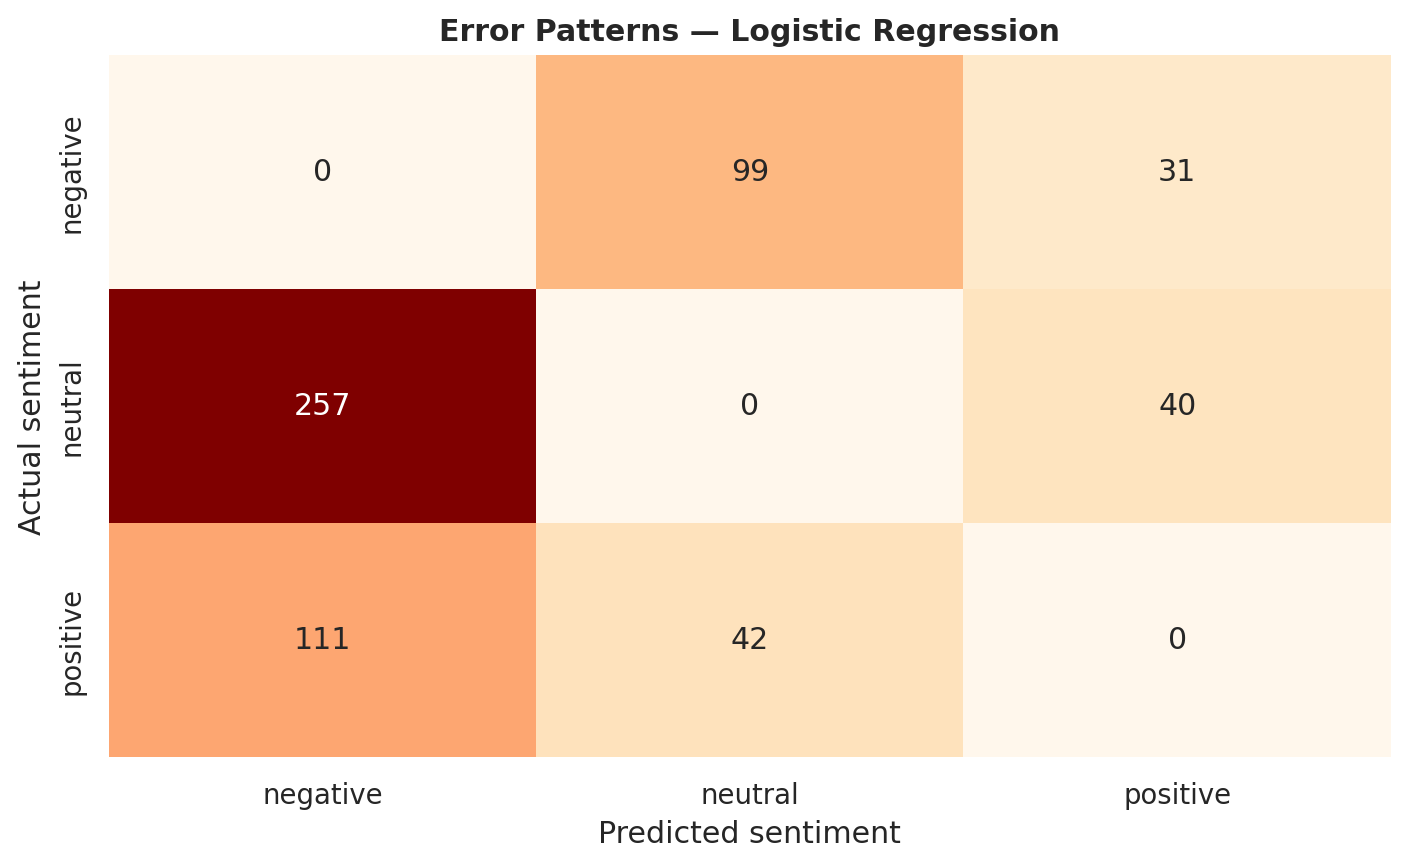

In [19]:
error_pairs = (
    errors.groupby(["Actual", "Predicted"], observed=True)
    .size()
    .rename("Errors")
    .reset_index()
    .sort_values("Errors", ascending=False)
)

display(error_pairs)

plt.figure(figsize=(8, 5))
error_matrix = (
    error_pairs.pivot(index="Actual", columns="Predicted", values="Errors")
    .reindex(index=LABEL_ORDER, columns=LABEL_ORDER)
    .fillna(0)
    .astype(int)
)
sns.heatmap(error_matrix, annot=True, fmt=",d", cmap="OrRd", cbar=False)
plt.title(f"Error Patterns — {best_model_name}")
plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_error_patterns.png", dpi=180, bbox_inches="tight")
plt.show()

### Discussion of likely errors

The examples above should be interpreted individually, but common causes include:

- **Short or ambiguous messages:** tweets such as “fine” or “okay then” depend heavily on context.
- **Mixed sentiment:** one tweet can contain both praise and criticism, while the dataset assigns only one label.
- **Negation:** TF-IDF bigrams help with phrases such as *not good*, but longer negation scope remains difficult.
- **Sarcasm and irony:** the literal words can express the opposite of the intended sentiment.
- **Slang, emojis, and creative spelling:** normalization can remove useful tone signals, while rare forms may not appear enough during training.
- **Annotation uncertainty:** sentiment labels are subjective, especially at the neutral boundaries.

These are limitations of a bag-of-words-style representation: TF-IDF records which terms occur, but it does not fully understand syntax, conversational context, or implied meaning.

## 11. Conclusion

The next cell generates the conclusion from the actual evaluation results, ensuring that the stated winner and reported scores match the run.

In [20]:
winner = results.index[0]
winner_metrics = results.loc[winner]
runner_up = results.index[1]
f1_difference = winner_metrics["F1-score (macro)"] - results.loc[runner_up, "F1-score (macro)"]

conclusion = f'''
### Final result

**{winner}** performed best using macro F1-score as the primary selection metric.

- Accuracy: **{winner_metrics['Accuracy']:.4f}**
- Macro precision: **{winner_metrics['Precision (macro)']:.4f}**
- Macro recall: **{winner_metrics['Recall (macro)']:.4f}**
- Macro F1-score: **{winner_metrics['F1-score (macro)']:.4f}**
- Macro F1 advantage over {runner_up}: **{f1_difference:.4f}**

The model can support **customer-feedback monitoring, brand or campaign tracking, support-ticket triage, product-review analysis, and public-opinion summaries**. In a production system, predictions should be monitored by humans when decisions affect customers, and the model should be retrained on recent, domain-specific examples.

### Limitations and next steps

1. Tweets are short, informal, and sometimes sarcastic.
2. TF-IDF does not fully represent word order or deeper context.
3. Performance may decline when the model is applied to another platform, language, topic, or time period.
4. Improvements could include hyperparameter tuning, character n-grams, emoji-aware preprocessing, a linear SVM, or a transformer model such as BERT.
'''

display(Markdown(conclusion))


### Final result

**Logistic Regression** performed best using macro F1-score as the primary selection metric.

- Accuracy: **0.7988**
- Macro precision: **0.7734**
- Macro recall: **0.7020**
- Macro F1-score: **0.7298**
- Macro F1 advantage over Multinomial Naive Bayes: **0.1261**

The model can support **customer-feedback monitoring, brand or campaign tracking, support-ticket triage, product-review analysis, and public-opinion summaries**. In a production system, predictions should be monitored by humans when decisions affect customers, and the model should be retrained on recent, domain-specific examples.

### Limitations and next steps

1. Tweets are short, informal, and sometimes sarcastic.
2. TF-IDF does not fully represent word order or deeper context.
3. Performance may decline when the model is applied to another platform, language, topic, or time period.
4. Improvements could include hyperparameter tuning, character n-grams, emoji-aware preprocessing, a linear SVM, or a tran

## 12. Predict sentiment for new text

This helper applies the **same preprocessing and fitted TF-IDF vectorizer** before prediction, which is essential for consistent inference.

In [21]:
def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]

    cleaned = [preprocess_text(text) for text in texts]
    features = tfidf.transform(cleaned)
    predicted_labels = best_model.predict(features)
    predicted_probabilities = best_model.predict_proba(features)

    return pd.DataFrame(
        {
            "text": texts,
            "clean_text": cleaned,
            "predicted_sentiment": predicted_labels,
            "confidence": predicted_probabilities.max(axis=1),
        }
    )


example_predictions = predict_sentiment(
    [
        "I absolutely love this product!",
        "The service was terrible and I want a refund.",
        "The package arrived this afternoon.",
    ]
)
display(example_predictions.assign(confidence=example_predictions["confidence"].round(4)))

                                            text  ... confidence
0                I absolutely love this product!  ...     0.6647
1  The service was terrible and I want a refund.  ...     0.9393
2            The package arrived this afternoon.  ...     0.7111

[3 rows x 4 columns]


## References

- [Kaggle — US Airline Twitter Sentiment Analysis dataset](https://www.kaggle.com/datasets/zahranusratt/us-airline-twitter-sentiment-analysis-dataset)
- [NLTK documentation](https://www.nltk.org/)
- [NLTK tokenizer API](https://www.nltk.org/api/nltk.tokenize.html)
- [scikit-learn — TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
- [scikit-learn — Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)
- [scikit-learn — Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [YouTube — Text Classification in Python: Sentiment Analysis with scikit-learn, Naive Bayes & TF-IDF](https://www.youtube.com/watch?v=f-ROinEvXQM)

---

**Checklist completed:** class distribution, preprocessing, TF-IDF explanation, 80/20 split, two classifiers, full evaluation, confusion matrices, WordClouds, five-example error analysis, model conclusion, and real-world applications.